# Prophet — An Illustrated Tour

> Prophet decomposes a time series into **trend + seasonality + holidays + noise**, fits it as a Bayesian additive model, and exposes each component for inspection.

$$y(t) = g(t) + s(t) + h(t) + \varepsilon_t.$$

---

**What we cover:**
- The additive decomposition
- Synthetic daily series with weekly + yearly seasonality
- Forecast with uncertainty intervals
- Plotting the trend / weekly / yearly components
- Adding custom holidays

## The picture — additive decomposition: trend + seasonality + holidays

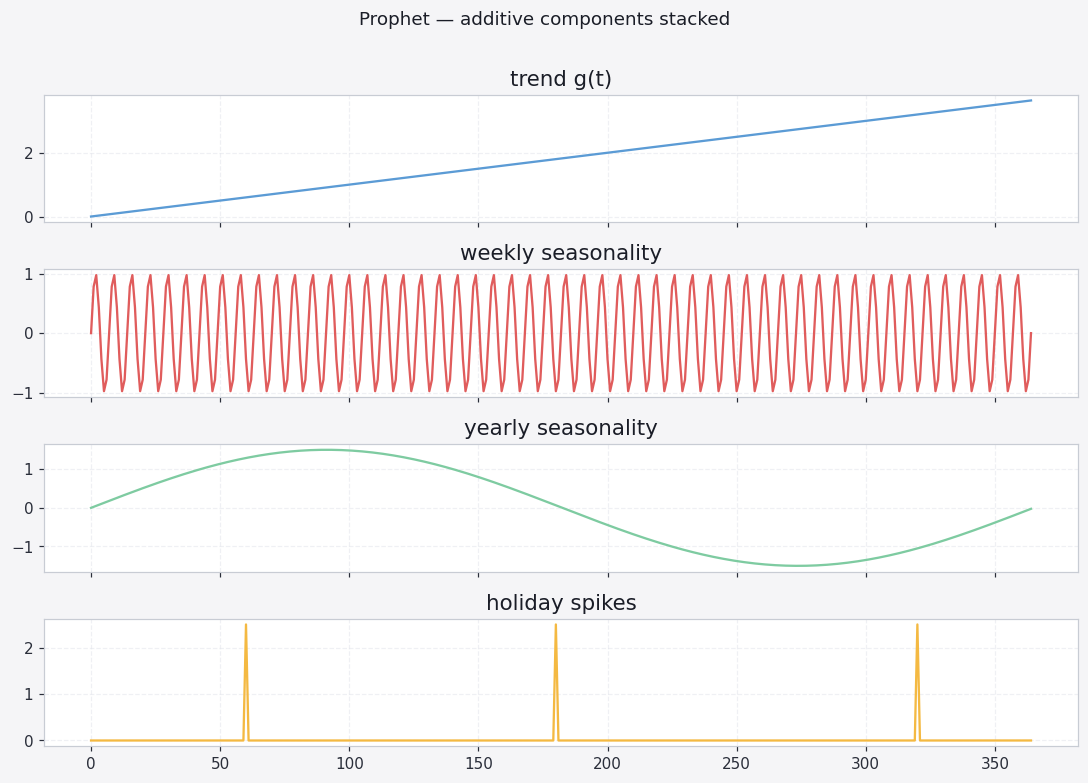

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
t = np.arange(365)
trend = 0.01*t
weekly = 1.0*np.sin(2*np.pi*t/7)
yearly = 1.5*np.sin(2*np.pi*t/365)
holidays = np.zeros_like(t, dtype=float)
holidays[[60, 180, 320]] = 2.5
total = trend + weekly + yearly + holidays
fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
for ax, y, c, lab in zip(axes, [trend, weekly, yearly, holidays + total*0.0001],
                          [P[0], P[1], P[3], P[2]],
                          ['trend g(t)', 'weekly seasonality', 'yearly seasonality', 'holiday spikes']):
    ax.plot(t, y, color=c, lw=1.5); ax.set_title(lab); ax.grid(True)
fig.suptitle('Prophet — additive components stacked', y=1.01)
plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging; logging.getLogger('prophet').setLevel(logging.WARNING); logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
from prophet import Prophet

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'

rng = np.random.default_rng(0)
n_days = 730
ds = pd.date_range('2022-01-01', periods=n_days, freq='D')
trend = 0.02 * np.arange(n_days)
weekly = 1.5 * np.sin(2*np.pi*np.arange(n_days)/7)
yearly = 5 * np.sin(2*np.pi*np.arange(n_days)/365.25)
noise = rng.normal(0, 1.0, n_days)
y = trend + weekly + yearly + 20 + noise
df = pd.DataFrame({'ds': ds, 'y': y})
print(df.head())

Importing plotly failed. Interactive plots will not work.


          ds          y
0 2022-01-01  20.125730
1 2022-01-02  21.146650
2 2022-01-03  22.314805
3 2022-01-04  21.073648
4 2022-01-05  19.237282


---
## Decomposition

- **Trend $g(t)$**: piecewise linear (or saturating logistic) with automatic change-points.
- **Seasonality $s(t)$**: Fourier series for each known period (weekly, yearly, custom).
- **Holidays $h(t)$**: extra dummies on user-supplied dates with their own coefficients.
- **Noise $\varepsilon_t$**: i.i.d. normal.

In [3]:
split = -120
df_train, df_test = df.iloc[:split], df.iloc[split:]
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
            interval_width=0.95, mcmc_samples=0)
m.fit(df_train)
future = m.make_future_dataframe(periods=120)
fc = m.predict(future)
fc_test = fc.iloc[split:]
print('Forecast columns sample:', fc.columns[:8].tolist())

16:34:41 - cmdstanpy - INFO - Chain [1] start processing


16:34:41 - cmdstanpy - INFO - Chain [1] done processing


Forecast columns sample: ['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower']


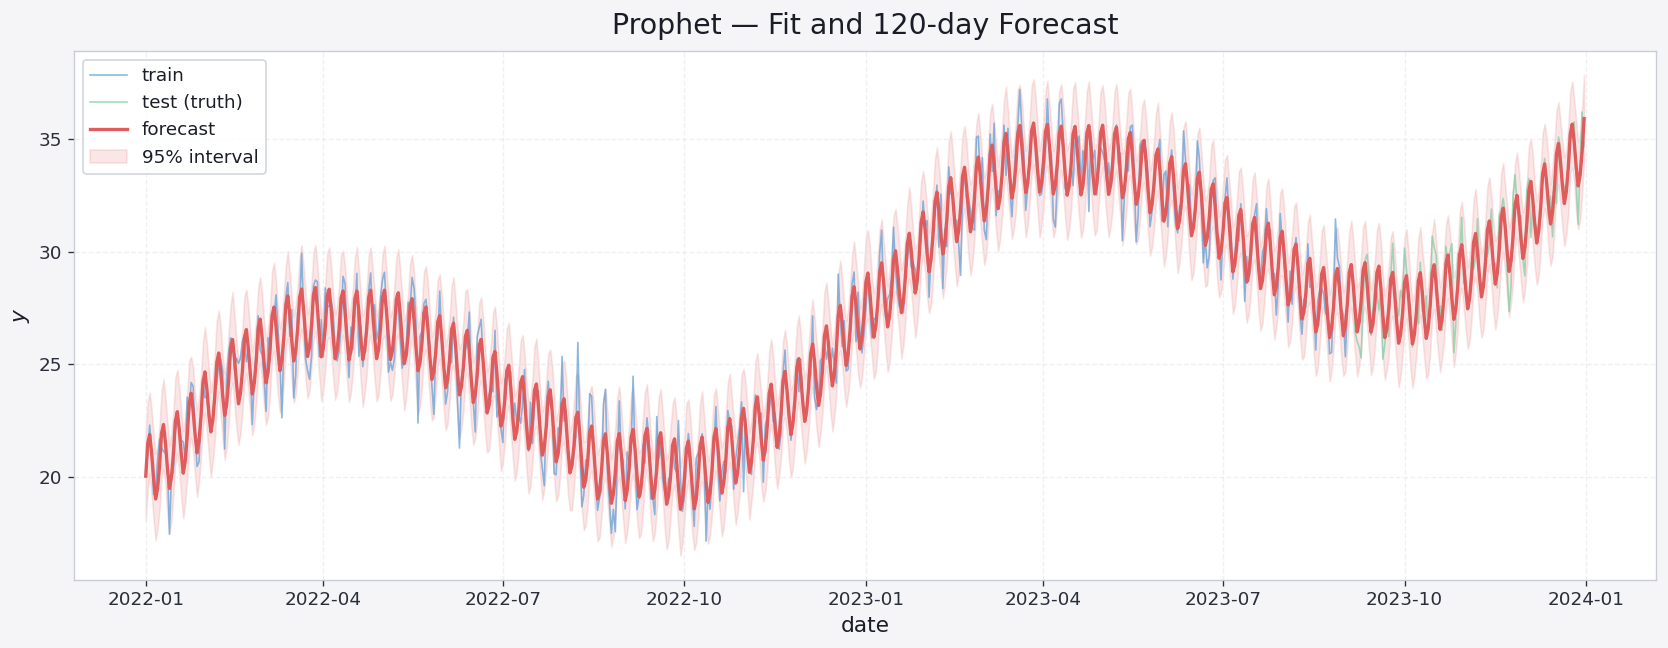

In [4]:
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(df_train['ds'], df_train['y'], color=C0, lw=1.0, alpha=0.7, label='train')
ax.plot(df_test['ds'],  df_test['y'],  color=CM, lw=1.0, alpha=0.7, label='test (truth)')
ax.plot(fc['ds'], fc['yhat'], color=C1, lw=2.0, label='forecast')
ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'], color=C1, alpha=0.15, label='95% interval')
ax.set_xlabel('date'); ax.set_ylabel('$y$'); ax.legend()
ax.set_title('Prophet — Fit and 120-day Forecast', pad=10); ax.grid(True)
plt.tight_layout(); plt.show()

---
## Components Plot

Prophet exposes each piece of the additive model. Here are trend, weekly seasonality and yearly seasonality, drawn separately.

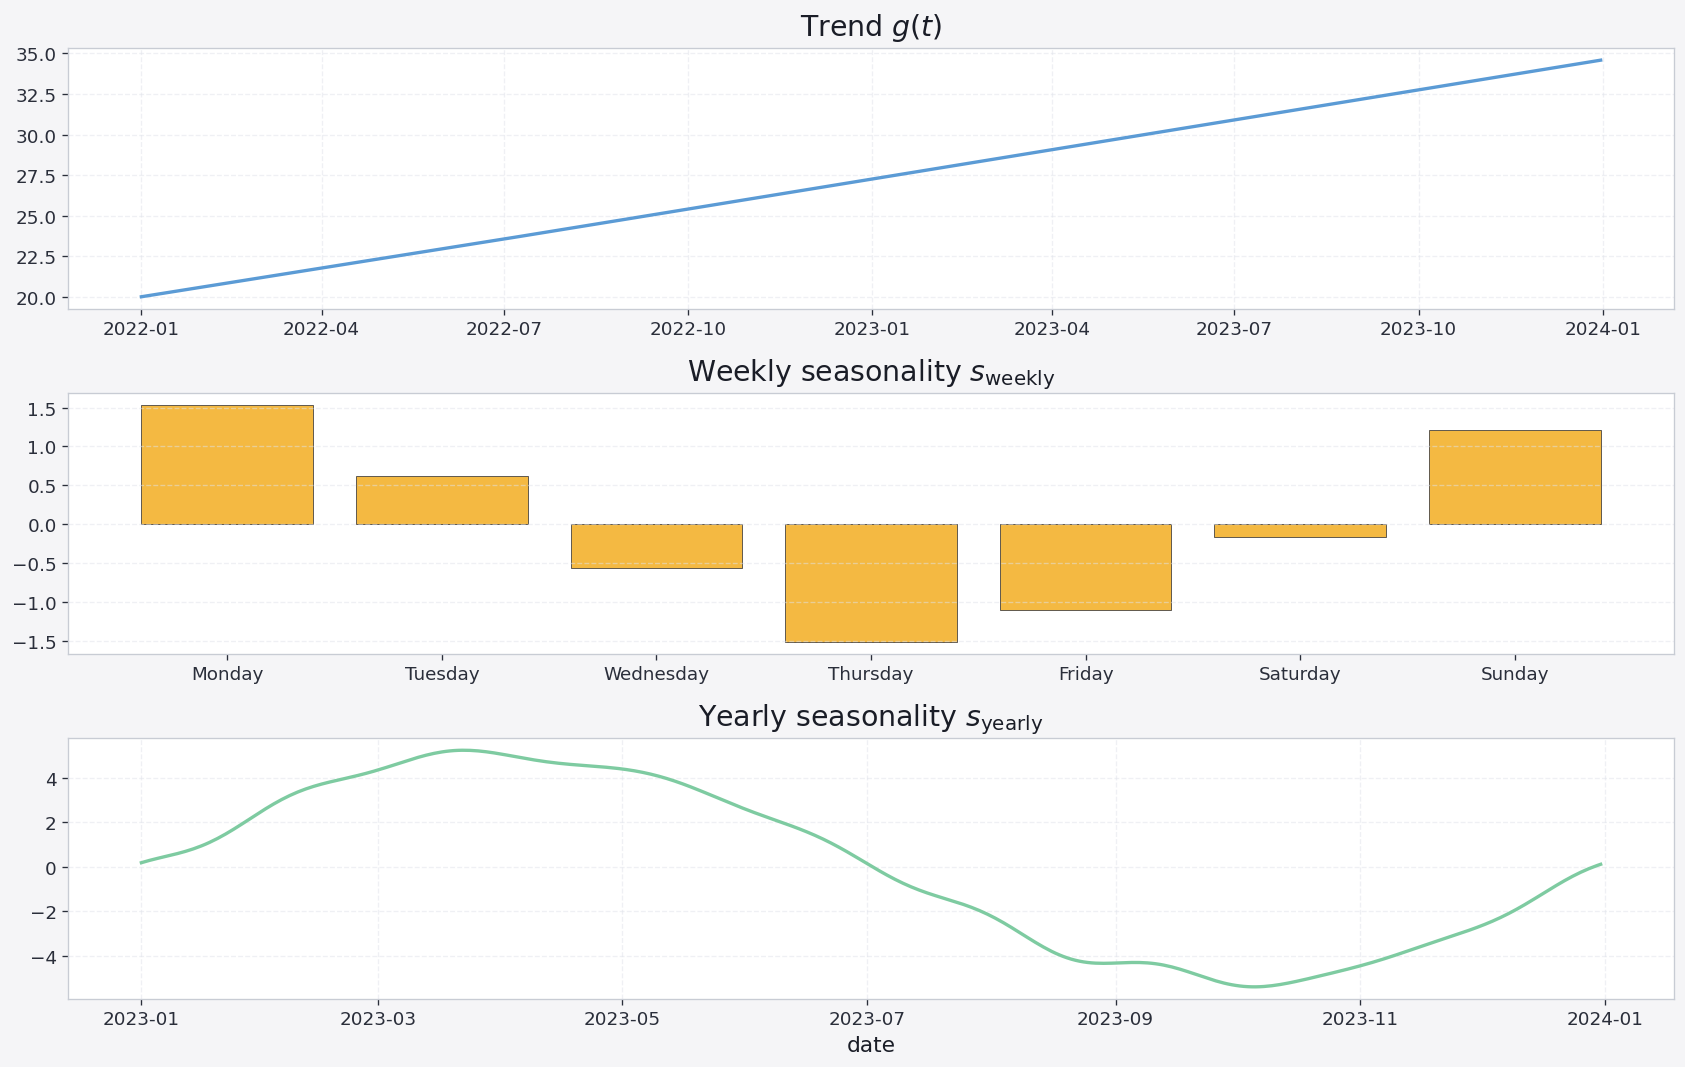

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
axes[0].plot(fc['ds'], fc['trend'], color=C0, lw=2.0)
axes[0].set_title('Trend $g(t)$', pad=8); axes[0].grid(True)

weekly_curve = fc.drop_duplicates('ds').set_index('ds')['weekly']
wk = (weekly_curve.iloc[-7:]).reset_index()
wk['day'] = wk['ds'].dt.day_name()
axes[1].bar(wk['day'], wk['weekly'], color=CB, edgecolor='#1a1d27', lw=0.4)
axes[1].set_title('Weekly seasonality $s_{\\mathrm{weekly}}$', pad=8); axes[1].grid(True, axis='y')

yr = fc[['ds', 'yearly']].drop_duplicates('ds').iloc[-365:]
axes[2].plot(yr['ds'], yr['yearly'], color=CM, lw=2.0)
axes[2].set_title('Yearly seasonality $s_{\\mathrm{yearly}}$', pad=8); axes[2].grid(True)
axes[2].set_xlabel('date')
plt.tight_layout(); plt.show()

---
## Adding Custom Holidays

Holidays / promotions / outage days enter as one-off effects. Pass a DataFrame with `holiday`, `ds` and optional `lower_window` / `upper_window`.

16:34:42 - cmdstanpy - INFO - Chain [1] start processing


16:34:42 - cmdstanpy - INFO - Chain [1] done processing


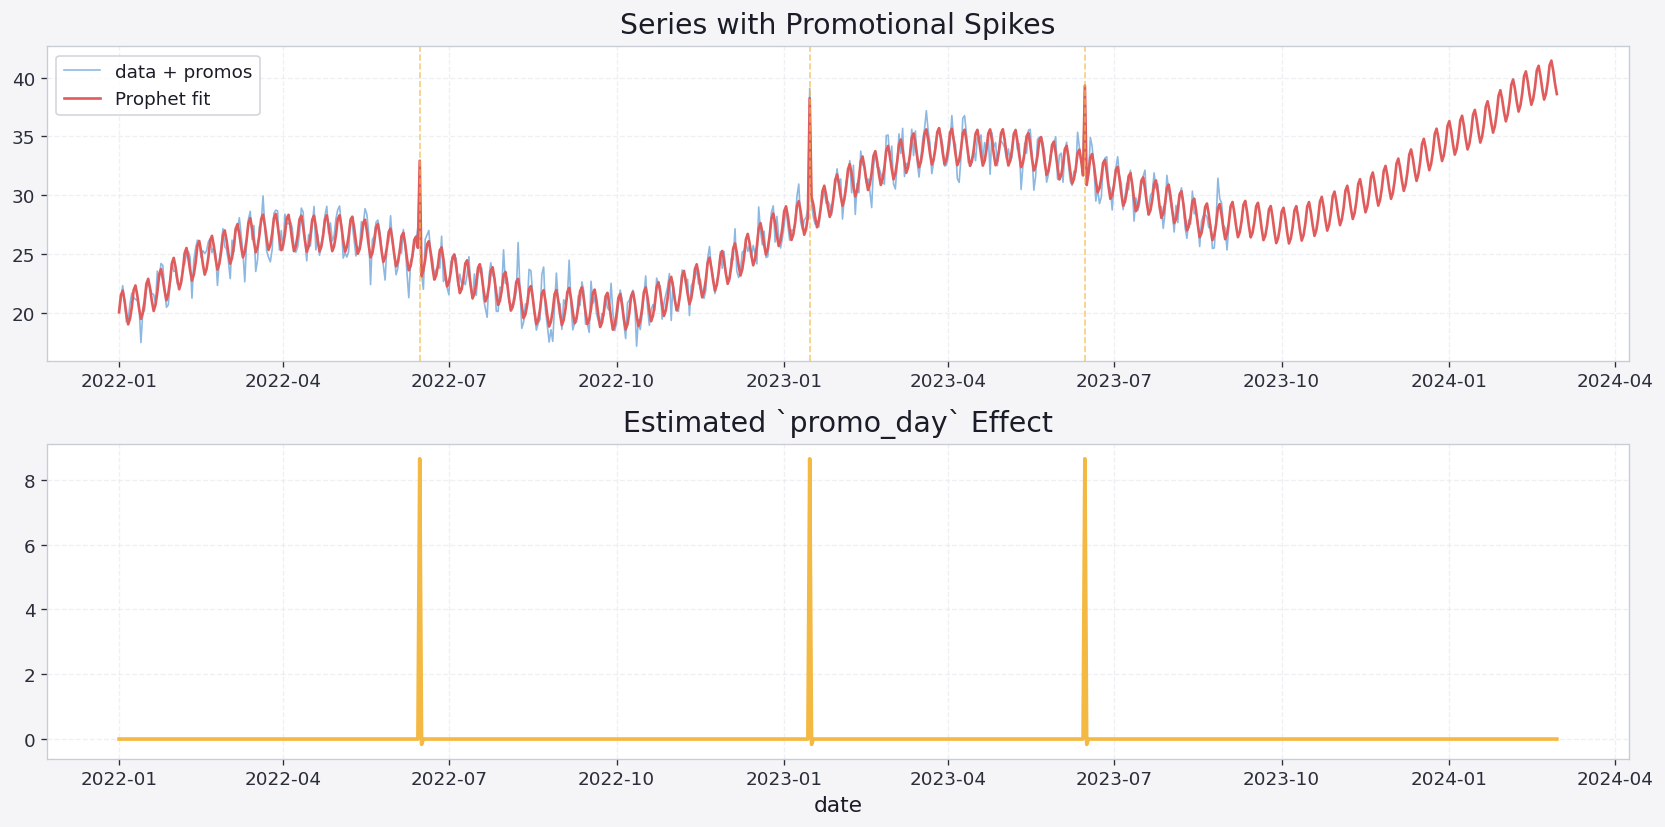

In [6]:
promos = pd.DataFrame({
    'holiday': 'promo_day',
    'ds': pd.to_datetime(['2022-06-15', '2023-01-15', '2023-06-15']),
    'lower_window': 0, 'upper_window': 1,
})
df_h = df_train.copy()
boost = df_h['ds'].isin(promos['ds']).values * 8.0
df_h['y'] = df_h['y'] + boost                              # inject promo lift in data
m2 = Prophet(holidays=promos, yearly_seasonality=True, weekly_seasonality=True,
             interval_width=0.95).fit(df_h)
fc2 = m2.predict(m2.make_future_dataframe(periods=180))

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(df_h['ds'], df_h['y'], color=C0, lw=1.0, alpha=0.7, label='data + promos')
axes[0].plot(fc2['ds'], fc2['yhat'], color=C1, lw=1.6, label='Prophet fit')
for d in promos['ds']:
    axes[0].axvline(d, color=CB, lw=1, ls='--', alpha=0.7)
axes[0].legend(); axes[0].grid(True); axes[0].set_title('Series with Promotional Spikes', pad=8)
axes[1].plot(fc2['ds'], fc2['promo_day'], color=CB, lw=2.2)
axes[1].set_title('Estimated `promo_day` Effect', pad=8); axes[1].grid(True); axes[1].set_xlabel('date')
plt.tight_layout(); plt.show()

---
## ⚖️ When to use Prophet — and when not to

| Situation | Prophet | ARIMA | LSTM |
|---|---|---|---|
| Multiple seasonalities + holidays | ✅ designed for it | ❌ | partial |
| Missing data / irregular sampling | ✅ | ❌ | partial |
| Interpretable components | ✅ trend + seasonality | partial | ❌ |
| State-of-the-art accuracy | partial | partial | ✅ |

> Prophet is built for **business series** — daily traffic, sales, revenue — not for low-noise physical processes.


---
## 🎯 Try this

1. **Change-point flexibility.** Sweep `changepoint_prior_scale` $\in \{0.01, 0.1, 0.5\}$. Larger = more flexible trend; too large and you overfit.
2. **Add a regressor.** Use `add_regressor` to include weather or marketing spend. Compare to vanilla Prophet — held-out RMSE should drop visibly when the regressor matters.
3. **Cross-validation.** Use `cross_validation` and `performance_metrics` from `prophet.diagnostics` to compute rolling-origin MAPE — Prophet has this built in.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Additive model | $y = g + s + h + \varepsilon$ | Each piece interpretable |
| Trend $g$ | Piecewise linear w/ change-points | Robust to long-term drift |
| Seasonality $s$ | Fourier series per period | Weekly + yearly default |
| Holidays $h$ | One-off dummies w/ windows | Promotions, outages, COVID |
| Uncertainty | Posterior simulations | `interval_width` controls coverage |
| Strength | Robust to missing data + outliers; minimal tuning | Battle-tested at Meta on millions of series |
| Weakness | Univariate; assumes additive structure; hard to add covariates | Use NeuralProphet / DeepAR for richer cases |

**Bottom line:** Prophet is the **business-analyst's forecaster** — hand it a daily series, get a robust, decomposable forecast that a non-statistician can debug.